# 05 — Exploratory Alternative Approaches

This notebook documents several alternative machine learning approaches explored during the development of the project.

The purpose of these experiments was to investigate different feature representations, dimensionality-reduction techniques, and classifiers before developing the final alternative approach used in Notebook 3.

The experiments are evaluated on the held-out validation dataset using Accuracy and Macro-F1.

The approaches explored are:

1. PCA + Distance-Based kNN
2. SelectKBest + 1-NN
3. PCA + Extra Trees
4. Tuned Extra Trees
5. HistGradientBoosting

The results from these experiments were used to guide the development of the final feature-enhanced ensemble approach presented in Notebook 3.

## 1. Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score

In [3]:
project_root = Path.cwd()

if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

data_dir = project_root / "data" / "raw"

train_df = pd.read_csv(data_dir / "trainingData.csv")
valid_df = pd.read_csv(data_dir / "validationData.csv")

wap_columns = [col for col in train_df.columns if col.startswith("WAP")]

X_train = train_df[wap_columns].copy()
X_valid = valid_df[wap_columns].copy()

y_train = train_df["FLOOR"].copy()
y_valid = valid_df["FLOOR"].copy()

# Convert the unobserved WAP marker to missing values
X_train = X_train.replace(100, np.nan)
X_valid = X_valid.replace(100, np.nan)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)
print("Number of WAP features:", len(wap_columns))

Training data: (19937, 520)
Validation data: (1111, 520)
Number of WAP features: 520


## 2. Evaluation Function

Each alternative approach is evaluated using the same validation dataset.

Two metrics are recorded:

- Accuracy
- Macro-F1

Macro-F1 gives equal importance to each floor class.

In [13]:
def evaluate_model(name, model, X_tr=X_train, X_val=X_valid):
    model.fit(X_tr, y_train)

    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_valid, predictions)
    macro_f1 = f1_score(y_valid, predictions, average="macro")

    print(f"{name}")
    print("-" * len(name))
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Macro-F1 : {macro_f1:.4f}")
    print()

    return {
        "Approach": name,
        "Accuracy": accuracy,
        "Macro-F1": macro_f1
    }

## 3. Alternative 1 — PCA + Distance-Based kNN

The first experiment combines PCA with a distance-based kNN classifier.

PCA reduces the dimensionality of the Wi-Fi fingerprint while kNN predicts the floor based on nearby fingerprints in the transformed feature space.

In [5]:
pca_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-105)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("model", KNeighborsClassifier(
        n_neighbors=1,
        metric="euclidean",
        n_jobs=-1
    ))
])

result_1 = evaluate_model(
    "PCA + Distance-Based kNN",
    pca_knn
)

c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


PCA + Distance-Based kNN
------------------------
Accuracy : 0.8353
Macro-F1 : 0.8290



c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


## 4. Alternative 2 — SelectKBest + 1-NN

The second experiment replaces PCA with supervised feature selection.

SelectKBest is used to retain the most informative Wi-Fi features before applying a 1-NN classifier.

In [6]:
select_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-105)),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=100)),
    ("model", KNeighborsClassifier(
        n_neighbors=1,
        metric="euclidean",
        n_jobs=-1
    ))
])

result_2 = evaluate_model(
    "SelectKBest + 1-NN",
    select_knn
)

c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


SelectKBest + 1-NN
------------------
Accuracy : 0.5950
Macro-F1 : 0.6297



c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


## 5. Alternative 3 — PCA + Extra Trees

The third experiment combines PCA-based dimensionality reduction with an Extra Trees classifier.

This tests whether a tree ensemble can perform effectively using a reduced feature representation.

In [7]:
pca_et = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-105)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

result_3 = evaluate_model(
    "PCA + Extra Trees",
    pca_et
)

c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


PCA + Extra Trees
-----------------
Accuracy : 0.8497
Macro-F1 : 0.8357



c:\Users\anvii\Downloads\wifi_indoor_localization_project\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['WAP003' 'WAP004' 'WAP092' 'WAP093' 'WAP094' 'WAP095' 'WAP152' 'WAP158'
 'WAP159' 'WAP160' 'WAP215' 'WAP217' 'WAP226' 'WAP227' 'WAP238' 'WAP239'
 'WAP240' 'WAP241' 'WAP242' 'WAP243' 'WAP244' 'WAP245' 'WAP246' 'WAP247'
 'WAP254' 'WAP293' 'WAP296' 'WAP301' 'WAP303' 'WAP304' 'WAP307' 'WAP333'
 'WAP349' 'WAP353' 'WAP360' 'WAP365' 'WAP416' 'WAP419' 'WAP423' 'WAP429'
 'WAP433' 'WAP438' 'WAP441' 'WAP442' 'WAP444' 'WAP445' 'WAP451' 'WAP458'
 'WAP482' 'WAP485' 'WAP487' 'WAP488' 'WAP491' 'WAP497' 'WAP520']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


## 6. Alternative 4 — Tuned Extra Trees

The fourth experiment evaluates Extra Trees without PCA.

The model is trained directly using the Wi-Fi RSSI representation with class balancing and multiple randomized decision trees.

In [8]:
tuned_et = ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

result_4 = evaluate_model(
    "Tuned Extra Trees",
    tuned_et
)

Tuned Extra Trees
-----------------
Accuracy : 0.9073
Macro-F1 : 0.8986



## 7. Alternative 5 — HistGradientBoosting with Signal Summary Features

The fifth experiment evaluates HistGradientBoosting using compact Wi-Fi signal summary features.

Instead of providing all 520 WAP measurements directly, the model uses statistics describing the observed Wi-Fi signals for each fingerprint.

This avoids the high-dimensional sparse representation used in the previous experiments and provides a different feature representation for the classifier.


In [16]:
# Create compact signal summary features

def create_summary_features(df, wap_columns):
    X = df[wap_columns].copy()
    X = X.replace(100, np.nan)

    summary = pd.DataFrame({
        "observed_wap_count": X.notna().sum(axis=1),
        "mean_rssi": X.mean(axis=1),
        "std_rssi": X.std(axis=1),
        "max_rssi": X.max(axis=1),
        "min_rssi": X.min(axis=1)
    }, index=X.index)

    # Replace any rows where a statistic is undefined
    summary = summary.replace([np.inf, -np.inf], np.nan)
    summary = summary.fillna(0)

    return summary


X_train_hist = create_summary_features(train_df, wap_columns)
X_valid_hist = create_summary_features(valid_df, wap_columns)

print("HistGradientBoosting training shape:", X_train_hist.shape)
print("HistGradientBoosting validation shape:", X_valid_hist.shape)

HistGradientBoosting training shape: (19937, 5)
HistGradientBoosting validation shape: (1111, 5)


In [17]:
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    random_state=42
)

result_5 = evaluate_model(
    "HistGradientBoosting",
    hist_gb,
    X_tr=X_train_hist,
    X_val=X_valid_hist
)

HistGradientBoosting
--------------------
Accuracy : 0.2925
Macro-F1 : 0.2257



In [18]:
exploratory_results = pd.DataFrame([
    result_1,
    result_2,
    result_3,
    result_4,
    result_5
])

display(exploratory_results)

,Approach,Accuracy,Macro-F1
0,PCA + Distance-Based kNN,0.835284,0.828973
1,SelectKBest + 1-NN,0.594959,0.629686
2,PCA + Extra Trees,0.849685,0.835744
3,Tuned Extra Trees,0.907291,0.898589
4,HistGradientBoosting,0.292529,0.225735


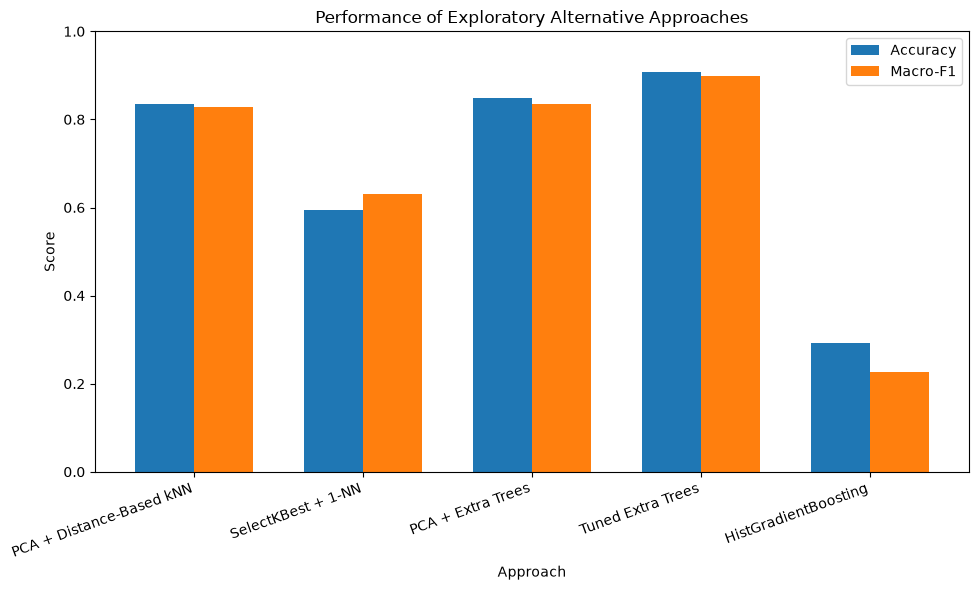

In [19]:
# Visualize exploratory alternative approaches

plt.figure(figsize=(10, 6))

x = np.arange(len(exploratory_results))
width = 0.35

plt.bar(
    x - width / 2,
    exploratory_results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    exploratory_results["Macro-F1"],
    width,
    label="Macro-F1"
)

plt.xticks(
    x,
    exploratory_results["Approach"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Approach")
plt.title("Performance of Exploratory Alternative Approaches")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "exploratory_alternatives.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Observations

The exploratory experiments produced different levels of performance:

- **PCA + Distance-Based kNN** achieved an Accuracy of 83.53% and Macro-F1 of 82.90%.
- **SelectKBest + 1-NN** achieved 59.50% Accuracy and 62.97% Macro-F1, showing that selecting a small subset of features can discard information useful for localization.
- **PCA + Extra Trees** achieved 84.97% Accuracy and 83.57% Macro-F1.
- **Tuned Extra Trees** improved the result to 90.73% Accuracy and 89.86% Macro-F1.
- **HistGradientBoosting using only the five Wi-Fi summary features** achieved 29.25% Accuracy and 22.57% Macro-F1.

These experiments show that the representation of the Wi-Fi fingerprint has a substantial effect on classification performance. In particular, reducing the original RSSI fingerprint to only a small set of summary statistics was insufficient for accurate floor prediction.

The exploratory results motivated the final alternative approach developed in Notebook 3. Instead of discarding the original RSSI information, the final approach retains the 520 WAP features and augments them with Wi-Fi signal summary features. Extra Trees and HistGradientBoosting are then combined using weighted probability averaging.

## 11. Transition to the Final Alternative Approach

The exploratory experiments provided a basis for selecting the components of the final alternative approach.

The final approach, developed separately in **Notebook 3**, combines the useful aspects identified during experimentation:

- the original 520 WAP RSSI features are retained,
- Wi-Fi availability and signal-strength summary features are added,
- Extra Trees is used to capture nonlinear relationships in the fingerprint,
- HistGradientBoosting provides a complementary tree-based model,
- weighted probability averaging is used to combine the two models.

The final approach is evaluated separately on the validation dataset and is compared with the paper-inspired baseline in Notebook 4.